In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedGroupKFold, learning_curve
from sklearn.metrics import make_scorer, f1_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.under_sampling import RandomUnderSampler

In [30]:
df_train = pd.read_csv('./Datos/df_voices_train.csv')

In [31]:
# Variable objetivo
df_train['y'] = df_train['Key'].map({
    'bonafide': 0,
    'spoof': 1
})

# Variables categóricas
if 'Gender' in df_train.columns:
    df_train = pd.get_dummies(
        df_train,
        columns=['Gender'],
        drop_first=True
    )

In [32]:
# Separar variables
drop_columns = ['Key', 'file_name', 'User_ID', 'Spoofing_ID', 'y']

X = df_train.drop(columns=drop_columns, errors='ignore')
y = df_train['y']

# Groups para evitar leakage
groups = df_train['Spoofing_ID']

print(f"Muestras: {X.shape[0]}")
print(f"Variables: {X.shape[1]}\n")


Muestras: 25380
Variables: 22



In [33]:
# ==========================================
# 1. MODELO
# ==========================================

pipeline = Pipeline([
    ('scaler', StandardScaler()),

    ('model', RandomForestClassifier(
        n_estimators=250,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    ))
])

In [34]:
# ==========================================
# 2. CROSS VALIDATION
# ==========================================

cv = StratifiedGroupKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [35]:
# ==========================================
# 3. LEARNING CURVE
# ==========================================

print("--- CALCULANDO LEARNING CURVE ---")

train_sizes, train_scores, validation_scores = learning_curve(
    estimator=pipeline,
    X=X,
    y=y,
    groups=groups,
    cv=cv,

    scoring=make_scorer(f1_score),

    # tamaños ABSOLUTOS
    train_sizes=np.arange(500, 10001, 500),

    n_jobs=-1,

    shuffle=True,
    random_state=42
)

# Promedios
train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)

validation_mean = np.mean(validation_scores, axis=1)
validation_std = np.std(validation_scores, axis=1)

--- CALCULANDO LEARNING CURVE ---


In [36]:
results_df = pd.DataFrame({
    'Muestras entrenamiento': train_sizes,
    'F1 Train': train_mean,
    'F1 Validation': validation_mean
})

print("\n==========================================")
print("RESULTADOS LEARNING CURVE")
print("==========================================\n")

print(results_df)



RESULTADOS LEARNING CURVE

    Muestras entrenamiento  F1 Train  F1 Validation
0                      500       1.0       0.930005
1                     1000       1.0       0.921538
2                     1500       1.0       0.914390
3                     2000       1.0       0.913697
4                     2500       1.0       0.912926
5                     3000       1.0       0.913221
6                     3500       1.0       0.912339
7                     4000       1.0       0.910056
8                     4500       1.0       0.907959
9                     5000       1.0       0.907213
10                    5500       1.0       0.905751
11                    6000       1.0       0.906326
12                    6500       1.0       0.906975
13                    7000       1.0       0.906300
14                    7500       1.0       0.906525
15                    8000       1.0       0.905854
16                    8500       1.0       0.905598
17                    9000       1.0

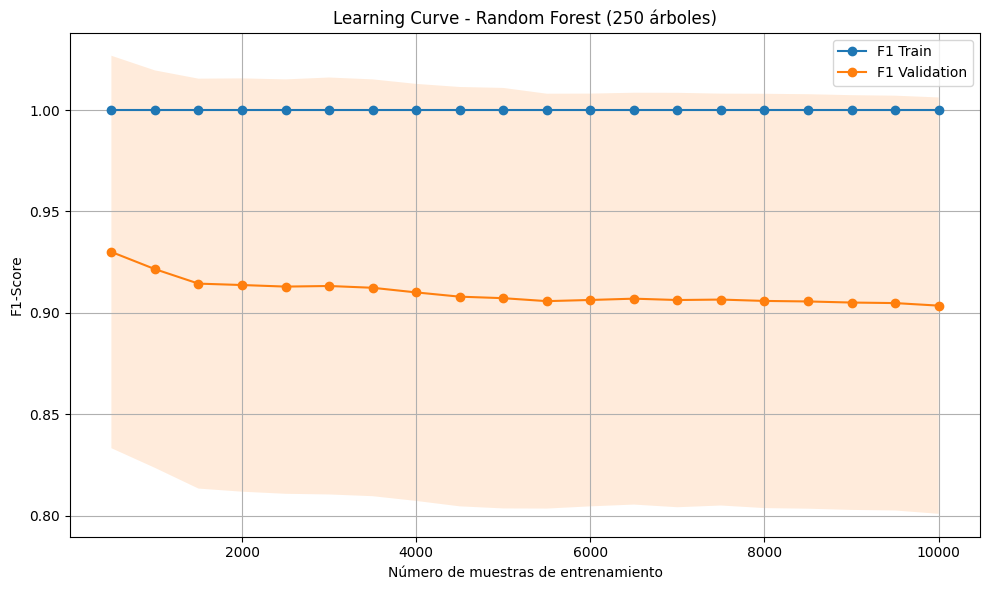

In [37]:
# ==========================================
# 4. GRÁFICA
# ==========================================

plt.figure(figsize=(10, 6))

# Train
plt.plot(
    train_sizes,
    train_mean,
    marker='o',
    label='F1 Train'
)

plt.fill_between(
    train_sizes,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.15
)

# Validation
plt.plot(
    train_sizes,
    validation_mean,
    marker='o',
    label='F1 Validation'
)

plt.fill_between(
    train_sizes,
    validation_mean - validation_std,
    validation_mean + validation_std,
    alpha=0.15
)

# Estética
plt.title('Learning Curve - Random Forest (250 árboles)')
plt.xlabel('Número de muestras de entrenamiento')
plt.ylabel('F1-Score')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()